# Kitaev Chain BdG Spectrum

**Model.** The Kitaev chain is represented as a single-particle Bogoliubov-de Gennes matrix in a doubled Nambu basis. The matrix has particle-hole symmetry: eigenvalues appear in $+E$ and $-E$ pairs.

**Typical uses.** Topological superconducting-chain examples, particle-hole symmetry checks, finite BdG spectra, and compact tests for algorithms on structured Hermitian matrices.

**Parameters.** `n_sites` sets the chain length $N$; `hopping` sets the normal hopping $t$; `chemical_potential` sets the chemical potential $\mu$; `pairing` sets the p-wave pairing amplitude $\Delta$; and `periodic` controls boundary wrapping.

**Useful plots.** Sorted BdG spectrum, particle-hole paired eigenvalues, and gap versus chemical potential.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from quantum_lattice_models.models import kitaev_chain_bdg
from quantum_lattice_models.plotting import plot_spectrum
from quantum_lattice_models.spectra import eigenvalues, spectral_gap

In [2]:
H = kitaev_chain_bdg(n_sites=12, hopping=1.0, chemical_potential=0.4, pairing=0.6)
values = np.sort(eigenvalues(H).real)
print("Kitaev BdG summary")
print(f"  matrix shape:              {H.shape}")
print(f"  hopping t:                 {H.metadata['hopping']:.2f}")
print(f"  chemical potential mu:     {H.metadata['chemical_potential']:.2f}")
print(f"  pairing Delta:             {H.metadata['pairing']:.2f}")
print(f"  particle-hole symmetric:   {np.allclose(values, -values[::-1])}")
print(f"  smallest absolute energy:  {np.min(np.abs(values)):.6e}")

Kitaev BdG summary
  matrix shape:              (24, 24)
  hopping t:                 1.00
  chemical potential mu:     0.40
  pairing Delta:             0.60
  particle-hole symmetric:   True
  smallest absolute energy:  3.593732e-04


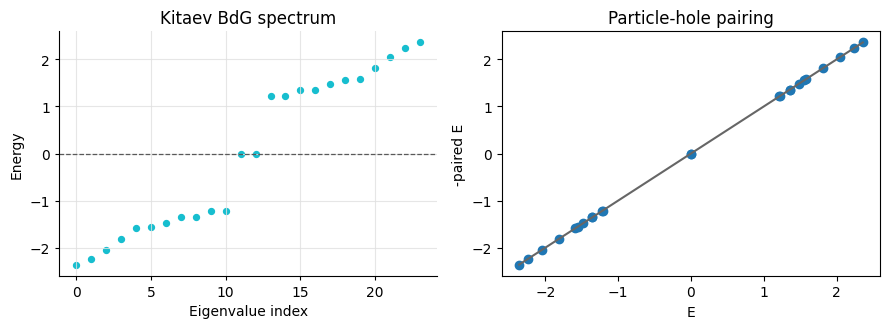

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
plot_spectrum(H, ax=axes[0], s=18, color="tab:cyan")
axes[0].axhline(0.0, color="0.35", linestyle="--", linewidth=0.9)
axes[0].set_title("Kitaev BdG spectrum")
axes[1].plot(values, -values[::-1], marker="o", linestyle="")
axes[1].plot([values.min(), values.max()], [values.min(), values.max()], color="0.4")
axes[1].set_xlabel("E")
axes[1].set_ylabel("-paired E")
axes[1].set_title("Particle-hole pairing")
fig.tight_layout()

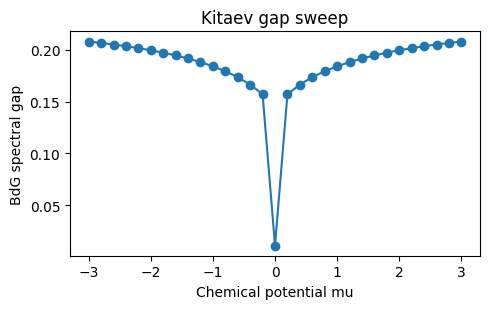

In [4]:
mu_values = np.linspace(-3.0, 3.0, 31)
gaps = [
    spectral_gap(kitaev_chain_bdg(n_sites=10, chemical_potential=float(mu), pairing=0.6))
    for mu in mu_values
]
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.plot(mu_values, gaps, marker="o")
ax.set_xlabel("Chemical potential mu")
ax.set_ylabel("BdG spectral gap")
ax.set_title("Kitaev gap sweep")
fig.tight_layout()